# Классификация изображений одежды (Fashion-MNIST)

**Задача:** по изображению предмета одежды 28×28 в градациях серого определить его
категорию — одну из 10 (футболка, брюки, свитер, платье, пальто, сандалии, рубашка,
кроссовки, сумка, ботинки).

**Тип:** многоклассовая классификация изображений (компьютерное зрение).
**Метрика:** accuracy на отложенной тестовой выборке.

## Загрузка данных

Данные подгружаются с публичного зеркала при первом запуске и парсятся из idx-формата.

In [1]:
import os
import gzip
import urllib.request

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_DIR = "data/fashion"
BASE_URL = "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/"
FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

os.makedirs(DATA_DIR, exist_ok=True)
for fname in FILES.values():
    dst = os.path.join(DATA_DIR, fname)
    if not os.path.exists(dst):
        urllib.request.urlretrieve(BASE_URL + fname, dst)


def read_images(path):
    with gzip.open(path, "rb") as f:
        return np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28)


def read_labels(path):
    with gzip.open(path, "rb") as f:
        return np.frombuffer(f.read(), np.uint8, offset=8)


X_train_full = read_images(os.path.join(DATA_DIR, FILES["train_images"]))
y_train_full = read_labels(os.path.join(DATA_DIR, FILES["train_labels"]))
X_test = read_images(os.path.join(DATA_DIR, FILES["test_images"]))
y_test = read_labels(os.path.join(DATA_DIR, FILES["test_labels"]))

CLASSES = [
    "футболка/топ", "брюки", "свитер", "платье", "пальто",
    "сандалии", "рубашка", "кроссовки", "сумка", "ботинки",
]

X_train_full.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

## Обзор данных

In [2]:
print("Обучающая выборка:", X_train_full.shape[0], "изображений")
print("Тестовая выборка: ", X_test.shape[0], "изображений")
print("Размер изображения:", tuple(X_train_full.shape[1:]),
      "| значения пикселей:", int(X_train_full.min()), "-", int(X_train_full.max()))
print()
counts = np.bincount(y_train_full)
for i, name in enumerate(CLASSES):
    print(f"{i}  {name:<14} {counts[i]}")

Обучающая выборка: 60000 изображений
Тестовая выборка:  10000 изображений
Размер изображения: (28, 28) | значения пикселей: 0 - 255

0  футболка/топ   6000
1  брюки          6000
2  свитер         6000
3  платье         6000
4  пальто         6000
5  сандалии       6000
6  рубашка        6000
7  кроссовки      6000
8  сумка          6000
9  ботинки        6000


Классы идеально сбалансированы — по 6000 изображений на каждый. Ниже — по одному
примеру на класс (слева-направо, сверху-вниз: классы 0…9 — футболка/топ, брюки, свитер,
платье, пальто, сандалии, рубашка, кроссовки, сумка, ботинки).

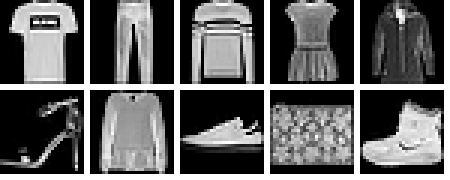

In [3]:
def sample_grid(images, labels, n_classes=10, scale=3, gap=2):
    """Собрать 2x5 сетку из одного примера каждого класса (PIL)."""
    tiles = [images[np.argmax(labels == c)] for c in range(n_classes)]
    rows = []
    for r in range(2):
        row = [np.pad(tiles[r * 5 + c], ((0, 0), (0, gap)), constant_values=255) for c in range(5)]
        rows.append(np.concatenate(row, axis=1))
    rows = [np.pad(row, ((0, gap), (0, 0)), constant_values=255) for row in rows]
    grid = np.concatenate(rows, axis=0).astype(np.uint8)
    img = Image.fromarray(grid)
    return img.resize((img.width * scale, img.height * scale), Image.NEAREST)


sample_grid(X_train_full, y_train_full)

## Подготовка данных

Пиксели нормируем в диапазон [0, 1] и добавляем размерность канала (изображения
одноканальные). От обучающей выборки отделяем 10% под валидацию (со стратификацией),
тест держим отдельно и не трогаем до финальной оценки.

In [4]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1,
    random_state=RANDOM_STATE, stratify=y_train_full,
)


def to_dataset(images, labels):
    x = torch.tensor(images / 255.0, dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(labels, dtype=torch.long)
    return TensorDataset(x, y)


train_loader = DataLoader(to_dataset(X_tr, y_tr), batch_size=256, shuffle=True)
val_loader = DataLoader(to_dataset(X_val, y_val), batch_size=256)
test_loader = DataLoader(to_dataset(X_test, y_test), batch_size=256)

len(X_tr), len(X_val), len(X_test)

(54000, 6000, 10000)

## Модель

Небольшая свёрточная сеть: два свёрточных блока (Conv → BatchNorm → ReLU → MaxPool)
наращивают число каналов 1 → 32 → 64 и вдвое уменьшают карту признаков, после чего
полносвязная голова с Dropout выдаёт логиты по 10 классам.

In [5]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = FashionCNN()
model

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=3136, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

## Обучение

Оптимизатор Adam, кросс-энтропия, 5 эпох. После каждой эпохи смотрим accuracy на валидации.

In [6]:
def evaluate(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / total


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 5

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    val_acc = evaluate(val_loader)
    print(f"эпоха {epoch:2d} | loss {running / len(train_loader.dataset):.4f} | val acc {val_acc:.4f}")

эпоха  1 | loss 0.4355 | val acc 0.8773
эпоха  2 | loss 0.3033 | val acc 0.9098
эпоха  3 | loss 0.2581 | val acc 0.9163
эпоха  4 | loss 0.2365 | val acc 0.9173
эпоха  5 | loss 0.2184 | val acc 0.9195


## Оценка на тесте

In [7]:
test_acc = evaluate(test_loader)
print(f"Accuracy на тесте: {test_acc:.4f}")

Accuracy на тесте: 0.9105


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
predictions = []
with torch.no_grad():
    for xb, _ in test_loader:
        predictions.append(model(xb).argmax(1).numpy())
y_pred = np.concatenate(predictions)

print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))

              precision    recall  f1-score   support

футболка/топ      0.906     0.809     0.855      1000
       брюки      0.995     0.978     0.986      1000
      свитер      0.834     0.904     0.868      1000
      платье      0.859     0.950     0.902      1000
      пальто      0.904     0.799     0.848      1000
    сандалии      0.993     0.969     0.981      1000
     рубашка      0.742     0.778     0.760      1000
   кроссовки      0.960     0.955     0.957      1000
       сумка      0.984     0.983     0.983      1000
     ботинки      0.950     0.980     0.965      1000

    accuracy                          0.910     10000
   macro avg      0.913     0.911     0.911     10000
weighted avg      0.913     0.910     0.911     10000



Матрица ошибок: где именно модель путает классы.

In [9]:
cm = confusion_matrix(y_test, y_pred)
print("строки — истинный класс, столбцы — предсказанный (индексы 0-9)\n")
print("    " + " ".join(f"{j:>4}" for j in range(10)))
for i in range(10):
    print(f"{i:>2}  " + " ".join(f"{cm[i, j]:>4}" for j in range(10)) + f"   {CLASSES[i]}")

строки — истинный класс, столбцы — предсказанный (индексы 0–9)

       0    1    2    3    4    5    6    7    8    9
 0   809    0   25   28    3    1  127    0    7    0   футболка/топ
 1     0  978    0   19    1    0    1    0    1    0   брюки
 2     9    1  904   10   32    0   44    0    0    0   свитер
 3     5    2    7  950    3    0   32    0    1    0   платье
 4     0    0   80   56  799    0   64    0    1    0   пальто
 5     0    0    0    0    0  969    0   21    0   10   сандалии
 6    68    1   66   35   46    0  778    0    6    0   рубашка
 7     0    0    0    0    0    3    0  955    0   42   кроссовки
 8     1    1    2    8    0    1    2    2  983    0   сумка
 9     1    0    0    0    0    2    0   17    0  980   ботинки


## Выводы

- Свёрточная сеть на Fashion-MNIST даёт **accuracy 0.910 на тесте**; за 5 эпох качество на
  валидации стабильно росло (0.877 → 0.920).
- Увереннее всего распознаются классы с характерной формой — брюки, сумка, ботинки,
  сандалии, кроссовки (f1 ≈ 0.96–0.99).
- Основные ошибки приходятся на визуально похожие «верхние» вещи: рубашка (recall 0.78),
  пальто (0.80), футболка/топ (0.81) — модель путает рубашку со свитером, футболкой и
  пальто. Это типичная для Fashion-MNIST сложность.
- Куда двигаться дальше: аугментации, более глубокая сеть, расписание learning rate,
  больше эпох обучения.